In [3]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn.datasets import fetch_atlas_schaefer_2018

from surfplot import Plot
from neuromaps.transforms import mni152_to_fslr


# =========================================================
# 設定
# =========================================================

csv_path = "../analysis_corr2/normal_mean/gpt2_pieman_to_bronx_mean_clean.csv"
output_path = "../analysis_corr2/figures/gpt2_brain_surface.png"

N_PARCELS = 400

# 可視化したい列
TARGET_COLUMN = "pred_vs_group"

# =========================================================
# CSV 読み込み
# =========================================================

df = pd.read_csv(csv_path)

print(df.head())

# 相関値取得
values = df[TARGET_COLUMN].values

print("number of parcels:", len(values))

if len(values) != N_PARCELS:
    raise ValueError(
        f"Expected {N_PARCELS} parcels, got {len(values)}"
    )

# =========================================================
# Schaefer Atlas 読み込み
# =========================================================

atlas = fetch_atlas_schaefer_2018(
    n_rois=N_PARCELS,
    yeo_networks=7,
    resolution_mm=2
)

# 修正ポイント
atlas_img = nib.load(atlas.maps)

# voxel data
atlas_data = atlas_img.get_fdata()

# =========================================================
# Parcel値を voxel に展開
# =========================================================

atlas_data = atlas_img.get_fdata()

brain_map = np.zeros(atlas_data.shape)

for i in range(N_PARCELS):
    brain_map[atlas_data == (i + 1)] = values[i]

corr_img = nib.Nifti1Image(
    brain_map,
    affine=atlas_img.affine
)

# =========================================================
# MNI -> fsLR surface
# =========================================================

lh, rh = mni152_to_fslr(
    corr_img,
    "32k"
)

# =========================================================
# 可視化
# =========================================================

vmax = np.max(np.abs(values))
vmin = -vmax

p = Plot(
    surf_lh=lh,
    surf_rh=rh,
    views=["lateral", "medial"],
    size=(1400, 900)
)

# left/right hemisphere にデータ追加
p.add_layer(
    {
        "left": lh,
        "right": rh
    },
    cmap="coolwarm",   # 青-white-赤
    color_range=(vmin, vmax),
    cbar=True
)

fig = p.build()

plt.suptitle(
    f"{TARGET_COLUMN}",
    fontsize=20
)

os.makedirs(
    os.path.dirname(output_path),
    exist_ok=True
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"saved: {output_path}")

   parcel  pred_vs_group  subj_vs_group  pred_vs_actual  pred_vs_other_story  \
0       0      -0.006169       0.092124       -0.036849             0.008728   
1       1      -0.006985       0.232715       -0.018736             0.007183   
2       2      -0.002726       0.046146        0.005681             0.000087   
3       3       0.004468       0.078881       -0.003296            -0.009773   
4       4      -0.003424       0.058203        0.017083             0.007156   

   pred_vs_other_story_group network  
0                   0.001266     Vis  
1                   0.001562     Vis  
2                  -0.002062     Vis  
3                   0.003970     Vis  
4                  -0.001297     Vis  
number of parcels: 400
[fetch_atlas_schaefer_2018] Dataset found in /home/y-sato/nilearn_data/schaefer_2018


ValueError: Surface be a path-like string, an instance of BSPolyData, or None

num values: 400
[fetch_atlas_schaefer_2018] Dataset found in /home/y-sato/nilearn_data/schaefer_2018


libGL error: glx: failed to create dri3 screen
libGL error: failed to load driver: nouveau
libGL error: failed to get magic
libGL error: failed to load driver: nouveau


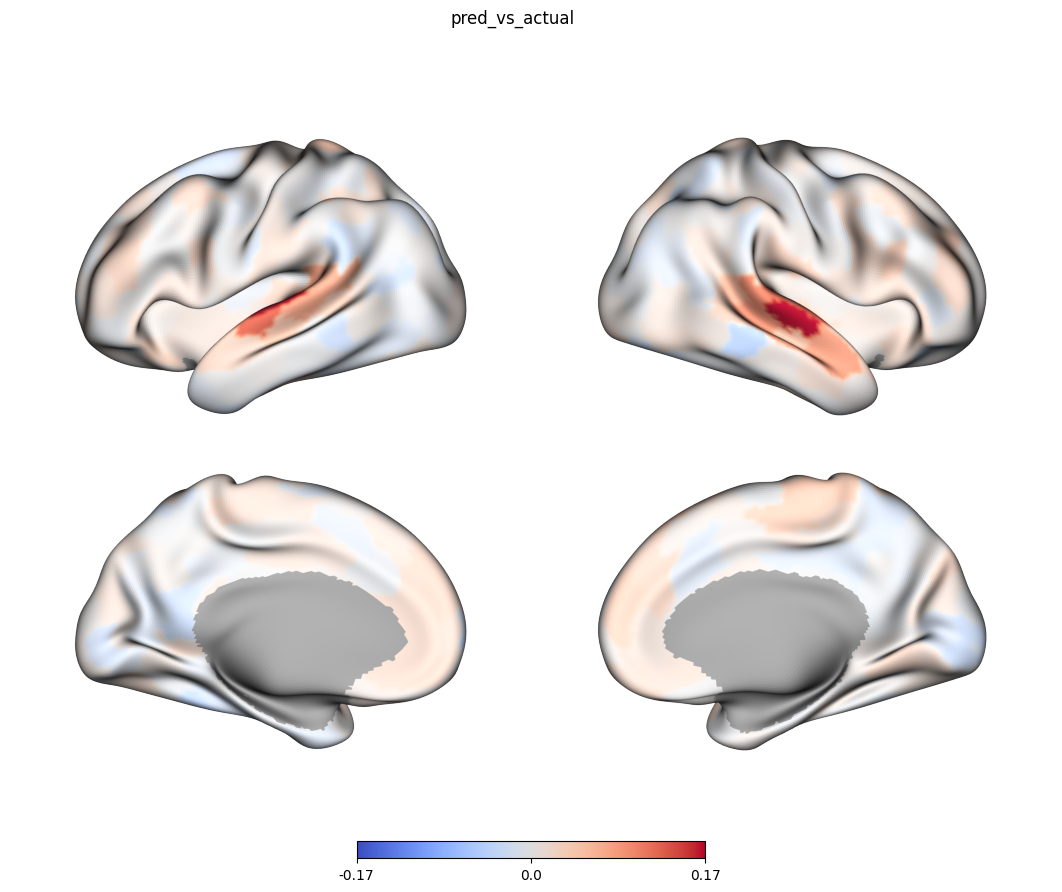

saved: ../analysis_corr2/figures/gpt2_brain_surface.png


In [5]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn.datasets import fetch_atlas_schaefer_2018

from neuromaps.transforms import mni152_to_fslr
from neuromaps.datasets import fetch_fslr

from surfplot import Plot


# =========================================================
# 設定
# =========================================================

csv_path = "../analysis_corr2/normal_mean/gpt2_pieman_to_bronx_mean_clean.csv"
output_path = "../analysis_corr2/figures/gpt2_brain_surface.png"

N_PARCELS = 400
TARGET_COLUMN = "pred_vs_actual"

# =========================================================
# CSV 読み込み
# =========================================================

df = pd.read_csv(csv_path)
values = df[TARGET_COLUMN].values

print("num values:", len(values))

# =========================================================
# Schaefer atlas
# =========================================================

atlas = fetch_atlas_schaefer_2018(
    n_rois=N_PARCELS,
    yeo_networks=7,
    resolution_mm=2
)

atlas_img = nib.load(atlas.maps)
atlas_data = atlas_img.get_fdata()

# =========================================================
# parcel -> voxel
# =========================================================

brain_map = np.zeros(atlas_data.shape)

for i in range(N_PARCELS):
    brain_map[atlas_data == (i + 1)] = values[i]

corr_img = nib.Nifti1Image(
    brain_map,
    affine=atlas_img.affine
)

# =========================================================
# MNI -> fsLR
# =========================================================

lh_data, rh_data = mni152_to_fslr(
    corr_img,
    "32k"
)

# =========================================================
# fsLR surface mesh
# =========================================================

surfaces = fetch_fslr()

lh_surf = surfaces["inflated"][0]
rh_surf = surfaces["inflated"][1]

# =========================================================
# plot
# =========================================================

vmax = np.max(np.abs(values))
vmin = -vmax

p = Plot(
    surf_lh=lh_surf,
    surf_rh=rh_surf,
    views=["lateral", "medial"],
    size=(1400, 900)
)

p.add_layer(
    {
        "left": lh_data,
        "right": rh_data
    },
    cmap="coolwarm",
    color_range=(vmin, vmax),
    cbar=True
)

fig = p.build()

plt.suptitle(TARGET_COLUMN)

os.makedirs(
    os.path.dirname(output_path),
    exist_ok=True
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("saved:", output_path)

num values: 400
[fetch_atlas_schaefer_2018] Dataset found in /home/y-sato/nilearn_data/schaefer_2018
[fetch_files] Downloading data from https://files.osf.io/v1/resources/4mw3a/providers/osfstorage/60b684aecb2a5e01fc68b7e1 ...
Downloaded 1261568 of 6550379 bytes (19.3%%,    4.2s remaining)
[fetch_files]  ...done. (3 seconds, 0 min)

[fetch_files] Extracting data from /home/y-sato/neuromaps-data/9e29c30a00cc86995f334ba48854d362/fsaverage41k.tar.gz...
[fetch_files] .. done.



libGL error: glx: failed to create dri3 screen
libGL error: failed to load driver: nouveau
libGL error: failed to get magic
libGL error: failed to load driver: nouveau


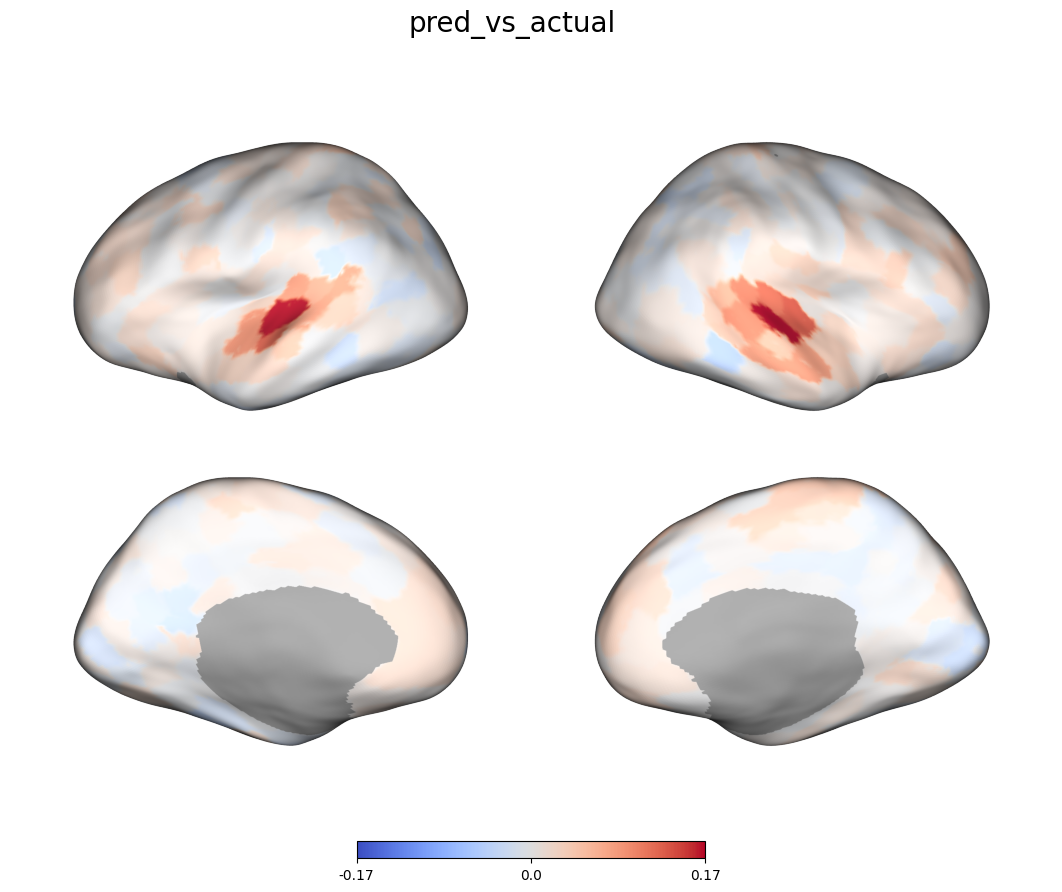

saved: ../analysis_corr2/figures/gpt2_fsaverage_surface.png


In [7]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn.datasets import fetch_atlas_schaefer_2018

from neuromaps.transforms import mni152_to_fsaverage
from neuromaps.datasets import fetch_fsaverage

from surfplot import Plot


# =========================================================
# 設定
# =========================================================

csv_path = "../analysis_corr2/normal_mean/gpt2_pieman_to_bronx_mean_clean.csv"
output_path = "../analysis_corr2/figures/gpt2_fsaverage_surface.png"

N_PARCELS = 400
TARGET_COLUMN = "pred_vs_actual"

# =========================================================
# CSV
# =========================================================

df = pd.read_csv(csv_path)
values = df[TARGET_COLUMN].values

print("num values:", len(values))

# =========================================================
# Schaefer atlas
# =========================================================

atlas = fetch_atlas_schaefer_2018(
    n_rois=N_PARCELS,
    yeo_networks=7,
    resolution_mm=2
)

atlas_img = nib.load(atlas.maps)
atlas_data = atlas_img.get_fdata()

# =========================================================
# parcel -> voxel
# =========================================================

brain_map = np.zeros(atlas_data.shape)

for i in range(N_PARCELS):
    brain_map[atlas_data == (i + 1)] = values[i]

corr_img = nib.Nifti1Image(
    brain_map,
    affine=atlas_img.affine
)

# =========================================================
# MNI -> fsaverage
# =========================================================

lh_data, rh_data = mni152_to_fsaverage(
    corr_img,
    "41k"
)

# =========================================================
# fsaverage surface
# =========================================================

surfaces = fetch_fsaverage("41k")

# veryinflated があれば最も滑らか
# 無ければ inflated を使う

if "veryinflated" in surfaces:
    lh_surf = surfaces["veryinflated"][0]
    rh_surf = surfaces["veryinflated"][1]
else:
    lh_surf = surfaces["inflated"][0]
    rh_surf = surfaces["inflated"][1]

# =========================================================
# plot
# =========================================================

vmax = np.max(np.abs(values))
vmin = -vmax

p = Plot(
    surf_lh=lh_surf,
    surf_rh=rh_surf,
    views=["lateral", "medial"],
    size=(1400, 900)
)

p.add_layer(
    {
        "left": lh_data,
        "right": rh_data
    },
    cmap="coolwarm",
    color_range=(vmin, vmax),
    cbar=True
)

fig = p.build()

plt.suptitle(
    TARGET_COLUMN,
    fontsize=20
)

os.makedirs(
    os.path.dirname(output_path),
    exist_ok=True
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("saved:", output_path)